In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, QuantileTransformer

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('my_dataframe.csv')

cols_to_drop = ['Length (mm)', 'Diameter (mm)', 'L/D', 'n_replicates']
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns] + ['Second Stress', 'Second Strain'])
y_stress = df['Second Stress']
y_strain = df['Second Strain']

print(f"Data Loaded: {X.shape[0]} mixes, {X.shape[1]} features ready.")

Data Loaded: 148 mixes, 16 features ready.


In [3]:
cat_cols = ['Fiber Type']
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

print("preprocessing done for categorical and numerical features")

preprocessing done for categorical and numerical features


In [4]:
models = {
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror'),
    'SVR': SVR(C=1.0, epsilon=0.1)
}

stress_preds = {}
strain_preds = {}
stress_r2_scores = {}
strain_r2_scores = {}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Models initialized. Ready for training.")

Models initialized. Ready for training.


In [5]:
print("Running 5-Fold Cross Validation for all models\n")

for name, model in models.items():
    pipe_stress = Pipeline([('preprocessor', preprocessor), ('model', model)])

    pipe_strain = Pipeline([
        ('preprocessor', preprocessor),
        ('model', TransformedTargetRegressor(
            regressor=model,
            transformer=QuantileTransformer(n_quantiles=min(len(df), 100), output_distribution='normal', random_state=42)
        ))
    ])

    y_pred_stress = cross_val_predict(pipe_stress, X, y_stress, cv=kf)
    y_pred_strain = cross_val_predict(pipe_strain, X, y_strain, cv=kf)

    r2_str = r2_score(y_stress, y_pred_stress)
    r2_stn = r2_score(y_strain, y_pred_strain)

    stress_r2_scores[name] = r2_str
    strain_r2_scores[name] = r2_stn
    stress_preds[name] = y_pred_stress
    strain_preds[name] = y_pred_strain

    print(f"[{name}] -> Stress R^2: {r2_str:.3f} | Strain R^2: {r2_stn:.3f}")

Running 5-Fold Cross Validation for all models

[Extra Trees] -> Stress R^2: 0.713 | Strain R^2: 0.292
[Random Forest] -> Stress R^2: 0.668 | Strain R^2: 0.280
[XGBoost] -> Stress R^2: 0.571 | Strain R^2: 0.096
[SVR] -> Stress R^2: 0.447 | Strain R^2: 0.228


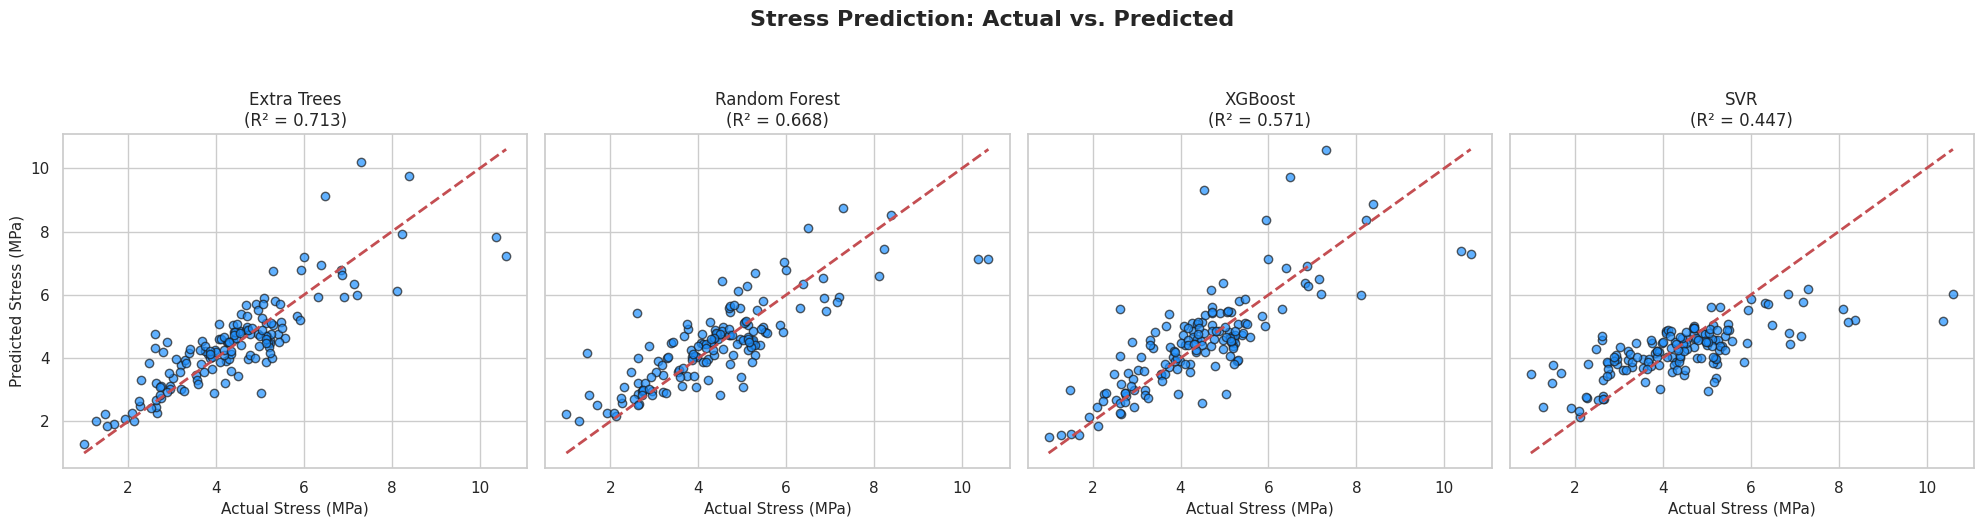

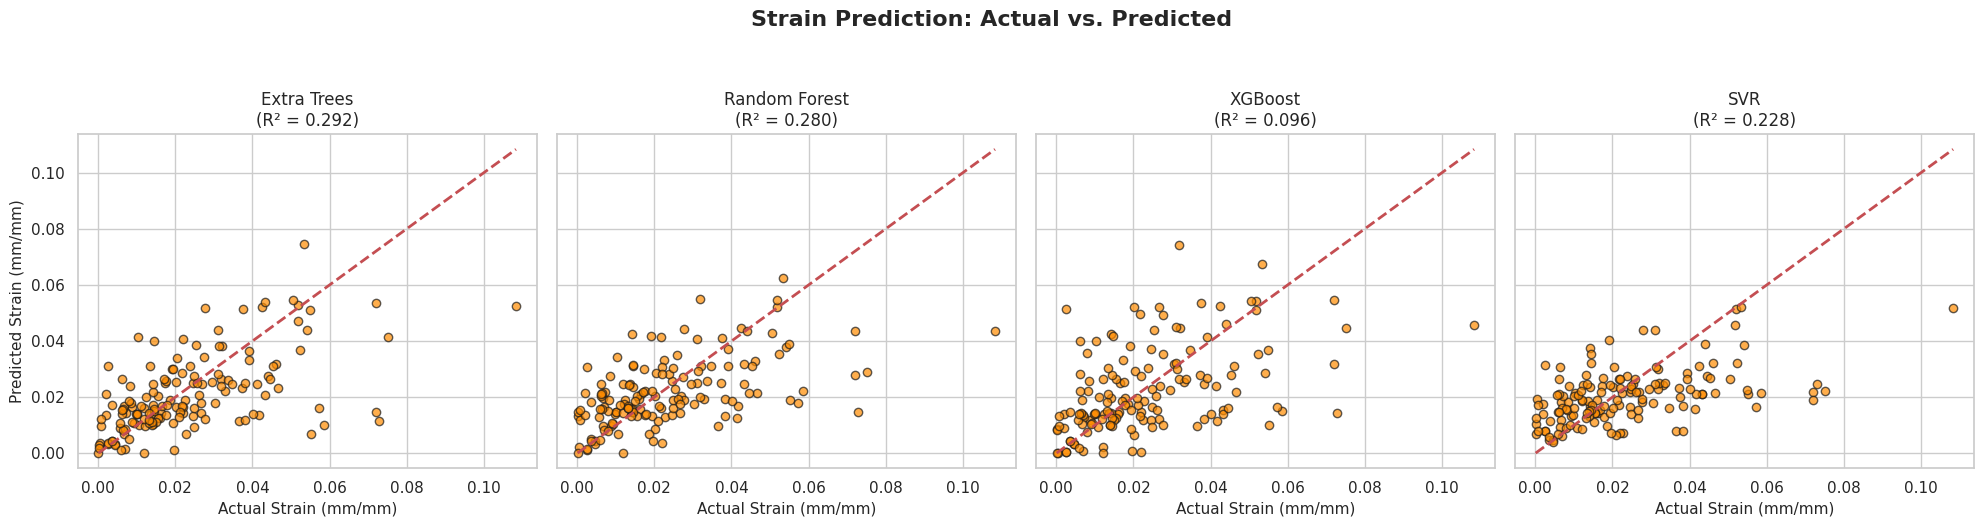

In [6]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.suptitle('Stress Prediction: Actual vs. Predicted', fontsize=16, fontweight='bold', y=1.05)

for ax, name in zip(axes, models.keys()):
    ax.scatter(y_stress, stress_preds[name], alpha=0.7, color='dodgerblue', edgecolor='k')
    ax.plot([y_stress.min(), y_stress.max()], [y_stress.min(), y_stress.max()], 'r--', lw=2)
    ax.set_title(f"{name}\n(R² = {stress_r2_scores[name]:.3f})", fontsize=12)
    ax.set_xlabel('Actual Stress (MPa)', fontsize=11)
    if ax == axes[0]: ax.set_ylabel('Predicted Stress (MPa)', fontsize=11)

plt.tight_layout()
plt.show()

# --- PLOT 2: STRAIN ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.suptitle('Strain Prediction: Actual vs. Predicted', fontsize=16, fontweight='bold', y=1.05)

for ax, name in zip(axes, models.keys()):
    ax.scatter(y_strain, strain_preds[name], alpha=0.7, color='darkorange', edgecolor='k')
    ax.plot([y_strain.min(), y_strain.max()], [y_strain.min(), y_strain.max()], 'r--', lw=2)
    ax.set_title(f"{name}\n(R² = {strain_r2_scores[name]:.3f})", fontsize=12)
    ax.set_xlabel('Actual Strain (mm/mm)', fontsize=11)
    if ax == axes[0]: ax.set_ylabel('Predicted Strain (mm/mm)', fontsize=11)

plt.tight_layout()
plt.show()

In [7]:
best_stress_model = Pipeline([('preprocessor', preprocessor), ('model', ExtraTreesRegressor(n_estimators=100, random_state=42))])
best_strain_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', TransformedTargetRegressor(
        regressor=ExtraTreesRegressor(n_estimators=100, random_state=42),
        transformer=QuantileTransformer(n_quantiles=min(len(df), 100), output_distribution='normal', random_state=42)
    ))
])

best_stress_model.fit(X, y_stress)
best_strain_model.fit(X, y_strain)

print("Extra Trees Model Trained")

Extra Trees Model Trained


In [8]:
default_vals = {}
for col in X.columns:
    if col in cat_cols:
        default_vals[col] = X[col].mode()[0]
    else:
        default_vals[col] = round(X[col].median(), 4)

style = {'description_width': '150px'}
input_widgets = {}

for col, val in default_vals.items():
    if col in cat_cols:
        input_widgets[col] = widgets.Dropdown(options=X[col].unique(), value=val, description=f"{col}:", style=style)
    else:
        input_widgets[col] = widgets.FloatText(value=val, description=f"{col}:", style=style)

predict_btn = widgets.Button(description="Predict Performance", button_style='success', icon='cogs')
output_area = widgets.Output()

def on_predict_clicked(b):
    with output_area:
        clear_output()
        user_input = {col: widget.value for col, widget in input_widgets.items()}
        input_df = pd.DataFrame([user_input])

        pred_stress = best_stress_model.predict(input_df)[0]
        pred_strain = best_strain_model.predict(input_df)[0]

        print("\n" + "="*50)
        print("PREDICTION RESULTS")
        print("="*50)
        print(f"Stress : {pred_stress:.3f} MPa")
        print(f"Strain : {pred_strain:.4f} mm/mm")
        print("="*50 + "\n")

predict_btn.on_click(on_predict_clicked)

print("Enter Mix Design Parameters Below")
vbox1 = widgets.VBox(list(input_widgets.values())[:len(input_widgets)//2])
vbox2 = widgets.VBox(list(input_widgets.values())[len(input_widgets)//2:])
ui = widgets.HBox([vbox1, vbox2])

display(ui, predict_btn, output_area)

Enter Mix Design Parameters Below


Button(button_style='success', description='Predict Performance', icon='cogs', style=ButtonStyle())

Output()